# Bayesian fundamentals: Motivating examples
**Author:** T.V.Q (James) <br>
**Date:** May 23, 2026

## 1. Overview
This report aims to visualize 2 bayesian motivating examples through simulation. Narrative about these 2 examples is presented in my Notion page

In [1]:
# Load Packages
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
# Set seed for the simulation
random_seed = 42

## 2. Example: real vs fake news
Summary:
From previous 150 articles fact checked by BuzzFeed journalists, there are 60 articles (40%) are fake and 90 articles (60%) are real.
  * Among the real articles, there were 2 (2/90 ~ 2.22%) articles containing exclamation point in its title
  * Among the fake articles, there were 16 (16/60 ~ 26.67%) articles containing exclamation point in its title

The question here is: suppose we encounter an article with an exclamation point in its title, could we conclude that it is fake? 
  From manual calculation, when an article contains exclamation point in its title, roughly 90% probability that the article is fake.

The analysis presented below demonstrate the simulation to visualize our finding.

### 2.1. Simulate prior distribution
Simulate a prior distribution of 10,000 articles

In [3]:
# Create the base for the simulation
#
#   pd.Series() function is used to create a pandas Series
#     data type of the Series is specified as category (dtype="category")
#     a Series only has a single unified dtype
#
#   pd.DataFrame() function is used to create a pandas DataFrame
#     there are several ways to use pd.DataFrame(), in this example we combine 2 pandas Series
#     with "column-name": <Series-name> is used to assign name to a column

article_type    = pd.Series(["Real", "Fake"], dtype="category")
prob_val        = pd.Series([0.6, 0.4])
type_prior_base = pd.DataFrame({"type": article_type, "weights": prob_val})

# Preview of the base
print(type_prior_base)

   type  weights
0  Real      0.6
1  Fake      0.4


In [4]:
# Simulate a prior distribution with 10,000 articles
#
#   sample() method is used to simulate random sample from "type_prior_base" dataframe
#     the number of simulated sample is 10,000 (n=10000)
#     the sampling method is sampling with replacement (replace=True)
#     the seed for the random number generator is fixed at specified "random_seed" value 
# 			(random_state=random_seed)
#     the "weights" column is used as the weighting probability (weights="weights")

type_prior_sim = type_prior_base.sample(n=10000, replace=True, random_state=random_seed, weights="weights")

# Verify the simulation
#
#   value_counts() method is used to count the frequency of unique values from an object
#     the object is "type" columns from "prior_sim" dataframe
#			percentage is given instead of counts (normalize=True)

type_prior_sim["type"].value_counts(normalize=True)

type
Real    0.6108
Fake    0.3892
Name: proportion, dtype: float64

### 2.2. Simulate the posterior distribution
For each row of the prior distribution, simulate the status of using exclamation point in the title

In [5]:
# Calculate the total number of real/fake articles
#
#   pandas boolean series is created by evaluating every row in "type" columns from 
# 		"type_prior_sim" dataframe (prior_sim["type"] == <value>)
#       => return True/False
#
#   sum() method is used to the boolean series
# 		the returned sum is equal to the number of True value

n_fake = (type_prior_sim["type"] == "Fake").sum()
n_real = (type_prior_sim["type"] == "Real").sum()

# Create the weight for status of using exclamation point in real/fake articles

w_fake = pd.Series([1 - 0.2667, 0.2667])
w_real = pd.Series([1 - 0.0222, 0.0222])

In [6]:
# Simulate the posterior distribution
#
#   loc() method is used to update values of the "usage" column from "type_prior_sim" dataframe
#			rows to be updated is filtered using type_prior_sim["type"] == <value>
#
#   np.random.choice() function is used to simulate the value from a chosen source
#     the chosen source is specified using ["No", "Yes"]
#     the simulation size must be specified to match exactly the number of rows 
# 			where type_prior_sim["type"] == <value>
#			if we remove this option, the function only pull one single random value and 
# 			every single selected row will get the same value
#     the sampling method is sampling with replacement (replace=True)
#     the weighting probability is specified as the weight for status of using exclamation point 
#       in real/fake articles (p=<value>

type_prior_sim.loc[type_prior_sim["type"] == "Fake", "usage"] = np.random.choice(
  ["No", "Yes"], size=n_fake, replace=True, p=w_fake
)

type_prior_sim.loc[type_prior_sim["type"] == "Real", "usage"] = np.random.choice(
  ["No", "Yes"], size=n_real, replace=True, p=w_real
)

# Reset index in the dataframe
#   dataframe with duplicate index values cannot passed into pd.crosstab() function
type_poster_sim = type_prior_sim.reset_index(drop=True)

# Verify the simulation
#  
#   pd.crosstab() function used to compute a cross-tabulation table of specified factors
#			percentage is given instead of counts (normalize="index")

pd.crosstab(type_poster_sim["usage"], type_poster_sim["type"], normalize="index")


type,Fake,Real
usage,,
No,0.322059,0.677941
Yes,0.900862,0.099138


### 2.3. Visualization of the posterior distribution

<Axes: xlabel='Using exclamation point in title?'>

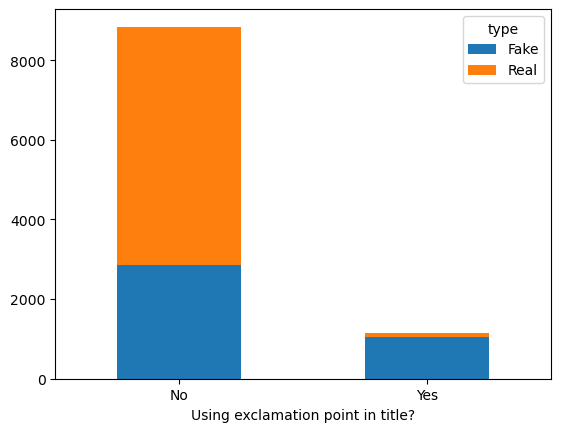

In [7]:
# Create a stacked bar chart
#		the cross-tabulation table is used as the data

pd.crosstab(type_poster_sim["usage"], type_poster_sim["type"]).plot(
    kind="bar", stacked=True, rot=0, xlabel="Using exclamation point in title?")

## 3. Example: chess winning probabilities
Summary:
* In 1996, the world chess champion Gary Kasparov played 6 chess games against the IBM supercomputer Deep Blue. Overall he won the match with 3 wins, 2 draws, and 1 loss. In 1997, he re-matched with the supercomputer with 6 games. However, he could only win 1 game, thus, lost the match.
* Before the 1996 match, we assign a prior distribution of the probability of Gary Kasparov winning a match ($\theta$) that puts more weight in his high chance of winning.
* After the 1996 match, we update our belief and put more weight in his medium chance of winning.
* After the 1997 match, we update our belief again and put more weight his medium/low chance of winning

### 3.1. Simulate prior distribution before 1996 match
Simulate a prior distribution of 10,000 values of $\theta$

In [8]:
# Create the base for the simulation
win_prob = pd.Series([0.2, 0.5, 0.8])
prob_val = pd.Series([0.1, 0.25, 0.65])

win_prior_base_1996 = pd.DataFrame({"winning chance": win_prob, "weights": prob_val})

# Simulate 10,000 values
win_prior_sim_1996 = win_prior_base_1996.sample(n=10000, replace=True, random_state=random_seed, weights="weights")

# Verify the simulation
win_prior_sim_1996["winning chance"].value_counts(normalize=True)

winning chance
0.8    0.6445
0.5    0.2524
0.2    0.1031
Name: proportion, dtype: float64

### 3.2. Simulate posterior distribution of 1996 match
Call $y$ is the number of wins in a 6-game match

In [9]:
# Simulate the number of wins
#		value of y is generated using np.random.binomial() function
#		np.random.binomial() is a funtion to simulate random sample using binomial distribution
#			the number of trials for binomial distribution is 6 (n=6)
#			the weighting probability is specified as the value in "winning chance" column 
#				from "win_prior_sim" dataframe (p=win_prior_sim["winning chance"])
# 		the total number of generated value is 10,000 (size=10000)

win_prior_sim_1996["y"] = np.random.binomial(n=6, p=win_prior_sim_1996["winning chance"], size=10000)

# Reset index in the dataframe
win_prior_sim_1996 = win_prior_sim_1996.reset_index(drop=True)

**Visualization of the simulation**

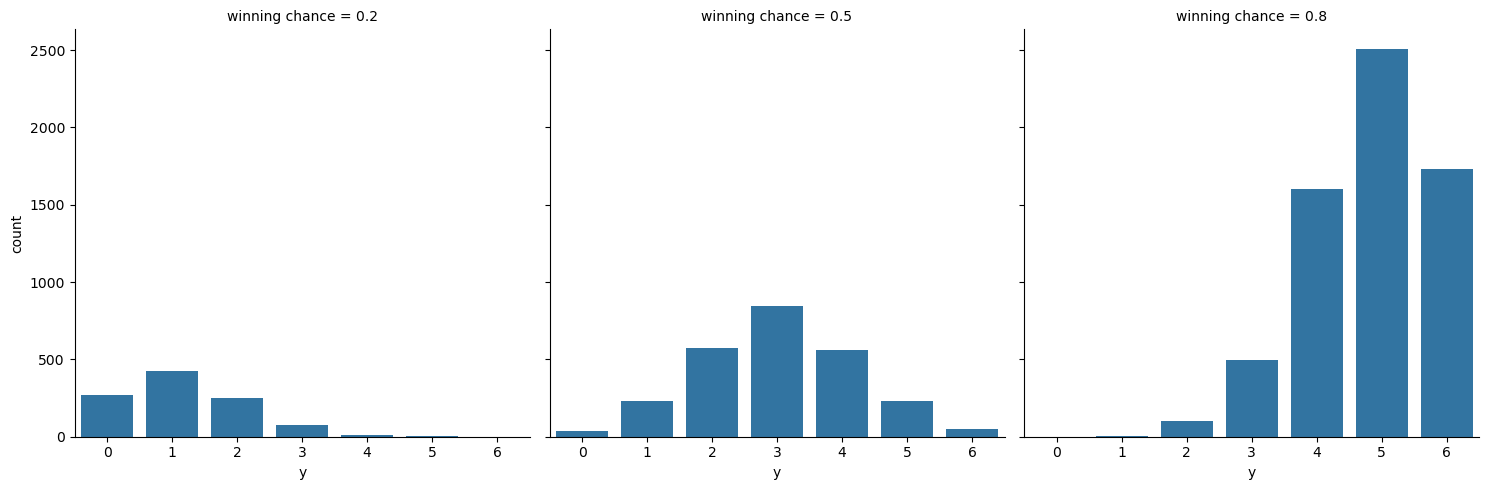

In [10]:
# Create bar charts for each probability of winning
rp = sns.catplot(x="y", col="winning chance", data=win_prior_sim_1996, kind="count")

The charts show that if the winning probability is high, there is more chance that the number of wins in a 6-game match is high
* With 0.8 probability of winning, there is more chance for Gary Kasparov to win 4, 5, or 6 games
* With 0.2 probability of winning, there is more chance for Gary Kasparov to win 0, 1, or 2 games

**Posterior distribution after 1996 match**

In [11]:
# Filter the posterior distribution
# 	number of wins is 3

win_poster_sim_1996 = win_prior_sim_1996[win_prior_sim_1996["y"] == 3]

win_poster_sim_1996["winning chance"].value_counts(normalize=True)

winning chance
0.5    0.596181
0.8    0.352192
0.2    0.051627
Name: proportion, dtype: float64

**Visualization of the posterior distribution**

<Axes: xlabel='winning chance', ylabel='Count'>

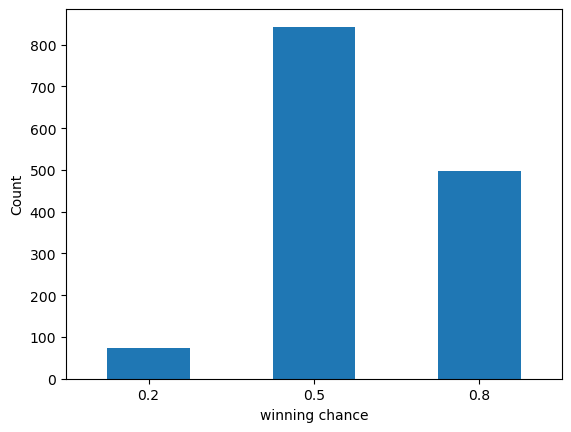

In [12]:
# Create a stacked bar chart
win_poster_sim_1996["winning chance"].value_counts().sort_index().plot(kind="bar", rot=0, ylabel="Count")

After the match, we re-allocate our belief, we do not put much of our belief in Gary Kasparov’s high chance of winning and put more of our belief in his medium chance of winning.

The posterior distribution of $\theta$ in 1996 would become the prior information for the 1997 re-match

### 3.3. Simulate prior distribution before 1997 match

In [13]:
# Create the base
win_prior_base_1997 = win_poster_sim_1996["winning chance"].value_counts(normalize=True).reset_index()

# Simulate 10,000 values
win_prior_sim_1997 = win_prior_base_1997.sample(n=10000, replace=True, random_state=random_seed, weights="proportion")

# Verify the simulation
win_prior_sim_1997["winning chance"].value_counts(normalize=True)

winning chance
0.5    0.6069
0.8    0.3441
0.2    0.0490
Name: proportion, dtype: float64

### 3.4. Simulate posterior distribution of 1997 match
Call $y$ is the number of wins in a 6-game match

In [14]:
# Simulate the number of wins
#		value of y is generated using np.random.binomial() function
#		np.random.binomial() is a funtion to simulate random sample using binomial distribution
#			the number of trials for binomial distribution is 6 (n=6)
#			the weighting probability is specified as the value in "winning chance" column 
#				from "win_prior_sim" dataframe (p=win_prior_sim["winning chance"])
# 		the total number of generated value is 10,000 (size=10000)

win_prior_sim_1997["y"] = np.random.binomial(n=6, p=win_prior_sim_1997["winning chance"], size=10000)

# Reset index in the dataframe
win_prior_sim_1997 = win_prior_sim_1997.reset_index(drop=True)

In [15]:
# Filter the posterior distribution
# 	number of wins is 1

win_poster_sim_1997 = win_prior_sim_1997[win_prior_sim_1997["y"] == 1]

win_poster_sim_1997["winning chance"].value_counts(normalize=True)

winning chance
0.5    0.778075
0.2    0.216578
0.8    0.005348
Name: proportion, dtype: float64

<Axes: xlabel='winning chance', ylabel='Count'>

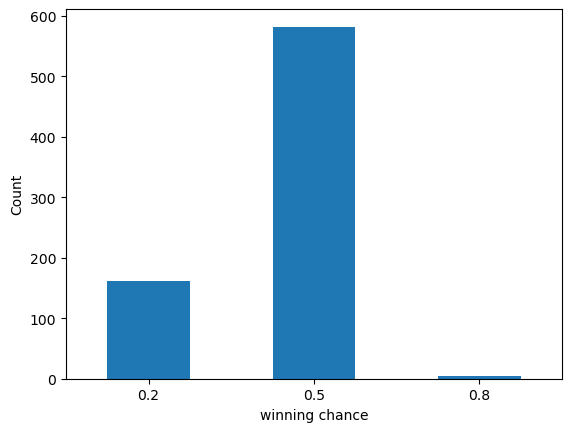

In [16]:
# Create a stacked bar chart
win_poster_sim_1997["winning chance"].value_counts().sort_index().plot(kind="bar", rot=0, ylabel="Count")

After the match, we re-allocate our belief again. Now we don’t believe that Gary Kasparov has high chance of winning and put more of our belief in his his medium/low chance of winning

In [17]:
%load_ext watermark
%watermark -n -u -v -iv

Last updated: Mon, 25 May 2026

Python implementation: CPython
Python version       : 3.14.5
IPython version      : 9.13.0

numpy  : 2.4.6
pandas : 3.0.3
seaborn: 0.13.2

